# Solutions · 09 · Activity-coefficient models

Worked solutions to the exercises of [notebook 09](../notebooks/09_activity_coefficient_models.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from engthermo import activity, datasets, vapor, vle
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

In [2]:
d = pd.read_csv(datasets.path("ethanol_water_vle_1atm.csv"), comment="#")
inner = d[(d.x_ethanol > 0) & (d.x_ethanol < 1)]
comps, p = ["ethanol", "water"], 101325.0
T = inner.T_C.to_numpy() + 273.15
fit_all = activity.fit("wilson", comps, inner.x_ethanol, T, p, y1=inner.y_ethanol)

## Exercise 1

Fit the Wilson model to only the data with x_ethanol < 0.5. How well does it predict the azeotrope? What does this say about extrapolating activity models beyond the data range?

In [3]:
low = inner.x_ethanol < 0.5
fit_low = activity.fit("wilson", comps, inner.x_ethanol[low], T[low], p, y1=inner.y_ethanol[low])
for name, f in (("all data", fit_all), ("x < 0.5 only", fit_low)):
    az = activity.azeotrope(comps, f["gamma"], p=p)
    print(f"{name:<13}: Lambda = {f['params']['Lambda'][0, 1]:.3f}, {f['params']['Lambda'][1, 0]:.3f}; azeotrope at x = {az['x1']:.3f}, {az['T']-273.15:.2f} degC")

all data     : Lambda = 0.307, 0.733; azeotrope at x = 0.890, 78.23 degC
x < 0.5 only : Lambda = 0.306, 0.734; azeotrope at x = 0.891, 78.23 degC


Fitted to the water-rich half only, the model recovers almost the same parameters and the same azeotrope.
That is suspiciously good, and there is a reason: this data file was generated from a Wilson model, so any
subset of it contains the whole model. With real data the two halves usually disagree, because the
parameters describing dilute ethanol in water are only loosely tied to those describing dilute water in
ethanol, and the azeotrope at x = 0.9 lies far from the water-rich data. The exercise's lesson survives the
synthetic data: extrapolation is where a fitted model is least trustworthy - and a perfect result should
make you ask why.

## Exercise 2

Using the fitted NRTL model, compute the minimum reflux-related quantity that matters most for a designer: the relative volatility $\alpha = y_1 x_2/(x_1 y_2)$ as a function of x_ethanol at 1 atm. Where does it fall below 1.1?

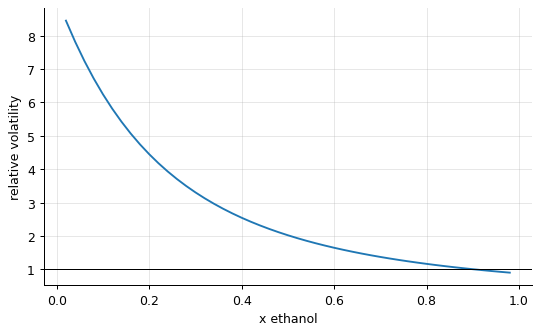

relative volatility falls below 1.1 above x = 0.84; it equals 1 at the azeotrope


In [4]:
fit_nrtl = activity.fit("nrtl", comps, inner.x_ethanol, T, p, y1=inner.y_ethanol)
xs = np.linspace(0.02, 0.98, 49)
alpha = []
for x in xs:
    r = vle.bubble_T(comps, [x, 1 - x], p, fit_nrtl["gamma"])
    y = r["y"][0]
    alpha.append(y * (1 - x) / (x * (1 - y)))
alpha = np.array(alpha)
plt.plot(xs, alpha); plt.axhline(1, color="k", lw=0.8); plt.xlabel("x ethanol"); plt.ylabel("relative volatility"); plt.show()
print(f"relative volatility falls below 1.1 above x = {xs[np.nonzero(alpha < 1.1)[0][0]]:.2f}; it equals 1 at the azeotrope")

The relative volatility of ethanol over water drops from about 10 in dilute solution to 1 at the azeotrope.
Above about 0.85 it is below 1.1, and each further tray of a column gains almost nothing - the practical
reason why distillation stops at 95 % ethanol even before the azeotrope is reached.

## Exercise 3

**Implement it yourself:** write a bubble-temperature solver with modified Raoult's law (activity coefficients from `activity.margules`) and reproduce the fitted T-x-y curve.

In [5]:
g = fit_all["gamma"]
def bubble_T(x1):
    f = lambda T: (x1 * g([x1, 1 - x1], T)[0] * vapor.antoine_psat("ethanol", T) + (1 - x1) * g([x1, 1 - x1], T)[1] * vapor.antoine_psat("water", T)) / p - 1
    return optimize.brentq(f, 300.0, 400.0)
xs = np.linspace(0.05, 0.95, 10)
lib = [vle.bubble_T(comps, [x, 1 - x], p, g)["T"] for x in xs]
print("agrees with the library to within 1e-9 K:", bool(np.max(np.abs(np.array([bubble_T(x) for x in xs]) - lib)) < 1e-9))

agrees with the library to within 1e-9 K: True


Modified Raoult's law adds the activity coefficients inside the same sum; because they depend on temperature
(weakly, for Wilson) the function is evaluated inside the root finder, which handles it without trouble.